# Init

In [1]:
%reload_ext autoreload
%autoreload 2

%config InlineBackend.figure_format = 'retina' # High-resolution plot outputs for Retina laptops

In [2]:
# Batteries
from datetime import datetime, timedelta
from pathlib import Path

# Externals
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import linear_model

# Experiment

In [3]:
path = Path('daily_national_incidence_2020-08-19.xlsx')
df = pd.read_excel(path)

In [4]:
df

,country,country_code,continent,population,indicator,daily_count,date,rate_14_day,source
0,Afghanistan,AFG,Asia,38928341,confirmed cases,0,2020-01-02,NaN,"Epidemic intelligence, national daily data"
1,Afghanistan,AFG,Asia,38928341,confirmed cases,0,2020-01-03,NaN,"Epidemic intelligence, national daily data"
2,Afghanistan,AFG,Asia,38928341,confirmed cases,0,2020-01-04,NaN,"Epidemic intelligence, national daily data"
3,Afghanistan,AFG,Asia,38928341,confirmed cases,0,2020-01-05,NaN,"Epidemic intelligence, national daily data"
4,Afghanistan,AFG,Asia,38928341,confirmed cases,0,2020-01-06,NaN,"Epidemic intelligence, national daily data"
...,...,...,...,...,...,...,...,...,...
99263,Zimbabwe,ZWE,Africa,14862927,deaths,0,2020-08-15,4.104171,"Epidemic intelligence, national daily data"
99264,Zimbabwe,ZWE,Africa,14862927,deaths,2,2020-08-16,4.104171,"Epidemic intelligence, national daily data"
99265,Zimbabwe,ZWE,Africa,14862927,deaths,2,2020-08-17,4.171453,"Epidemic intelligence, national daily data"
99266,Zimbabwe,ZWE,Africa,14862927,deaths,3,2020-08-18,3.700482,"Epidemic intelligence, national daily data"


# Func

## `predict_lr`

In [5]:
def predict_lr(country, X, y, X_pred, x_days):
    # Step: Predict
    regr = linear_model.LinearRegression()
    regr.fit(X, y)
    y_pred = regr.predict(X_pred)
    y_approximate = regr.predict(X)
    coef = regr.coef_
    
    # Step: Plot
    fig, ax = plt.subplots()
    ax.scatter(X, y, color='black')
    ax.plot(X, y_approximate, color='green', linewidth=3)
    
    ax.scatter(X_pred, y_pred, color='red')
    ax.plot(X_pred, y_pred, color='blue', linewidth=3)

    # Step: Notes
    nums = "Predict: " + ", ".join([str(round(x, 1)) for x in y_pred])
    xlabels = [x.strftime('%m.%d') for x in x_days]
    end = (-1) * len(X_pred)
    dates = ", ".join(xlabels[end:])
    title = f'{country}, {nums}\n@ {dates}\nK = {coef}'
    ax.set_title(title)
    plt.xticks(ticks=range(1, len(x_days)+1), labels=xlabels)

    # Step: Show
    fig.tight_layout()
    plt.show()

## `get_data`

In [6]:
def get_data(df, country, dt_range):
    """
    country = 'Germany'
    start_dt = '2020-07-01'
    end_dt = '2020-09-01'
    """
    ind = 'confirmed cases'
    cou = country
    sdt = dt_range[0]
    edt = dt_range[1]
    wd = 4  # friday
    
    query = 'indicator == @ind & country == @cou & date >= @sdt & date <= @edt & date.dt.weekday == @wd'
    new_df = df.query(query)
    return new_df.loc[:, 'date'], new_df.loc[:, 'rate_14_day']

## `create_x`

In [7]:
def create_x(days_fr, len_predict):
    X = np.arange(1, len(days_fr)+1)
    X = X.reshape((len(days_fr), 1))
    
    X_pred = np.arange(len(days_fr)+1, len(days_fr)+len_predict+1)
    X_pred = X_pred.reshape((len_predict, 1))
    
    dt0 = days_fr.iloc[0]
    x_days = [dt0 + timedelta(days=7)*x for x in range(len(X)+len(X_pred))]
    return X, X_pred, x_days

# Flow

## Load XLSX

In [8]:
path = Path('daily_national_incidence_2020-08-19.xlsx')
df = pd.read_excel(path)

## Turkey

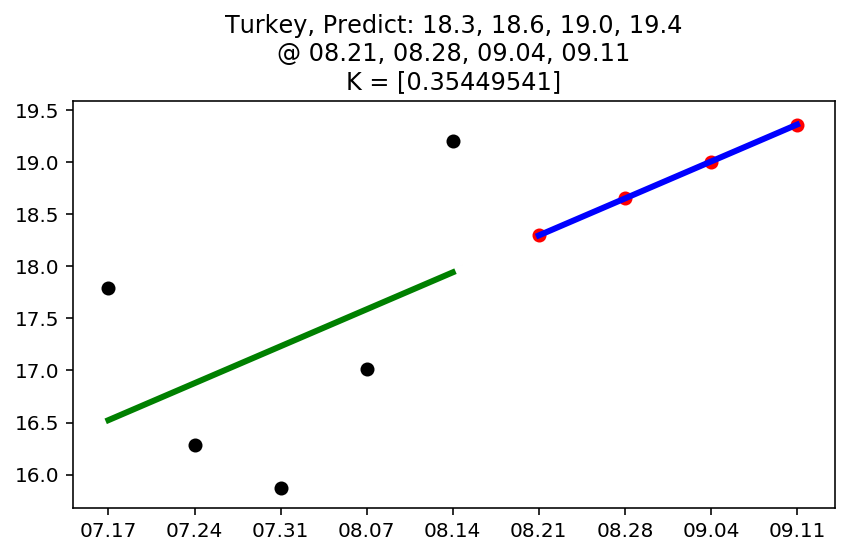

In [19]:
country = 'Turkey'
dt_range = ('2020-07-17', '2020-09-01')
len_predict = 4

days_fr, rate_14_day = get_data(df, country, dt_range)
X, X_pred, x_days = create_x(days_fr, len_predict)
y = rate_14_day

predict_lr(country, X, y, X_pred, x_days)

## Germany

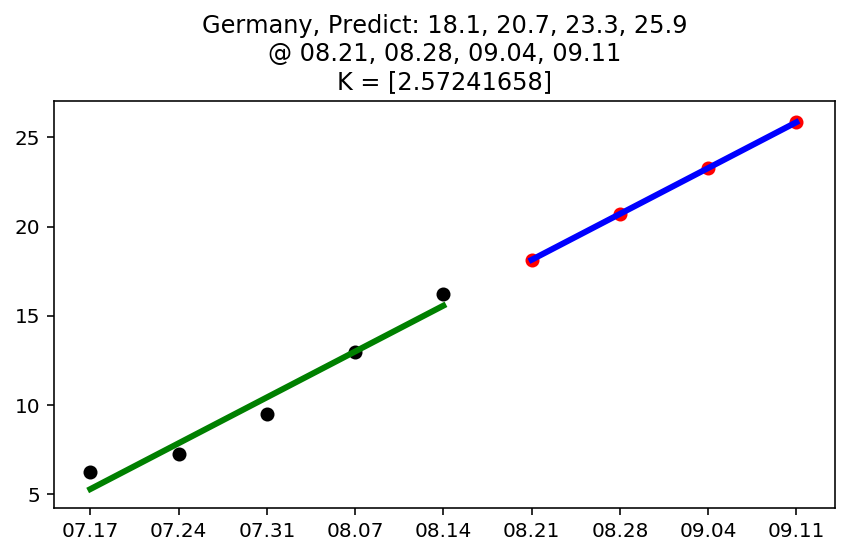

In [18]:
country = 'Germany'
dt_range = ('2020-07-17', '2020-09-01')
len_predict = 4

days_fr, rate_14_day = get_data(df, country, dt_range)
X, X_pred, x_days = create_x(days_fr, len_predict)
y = rate_14_day

predict_lr(country, X, y, X_pred, x_days)

## Latvia

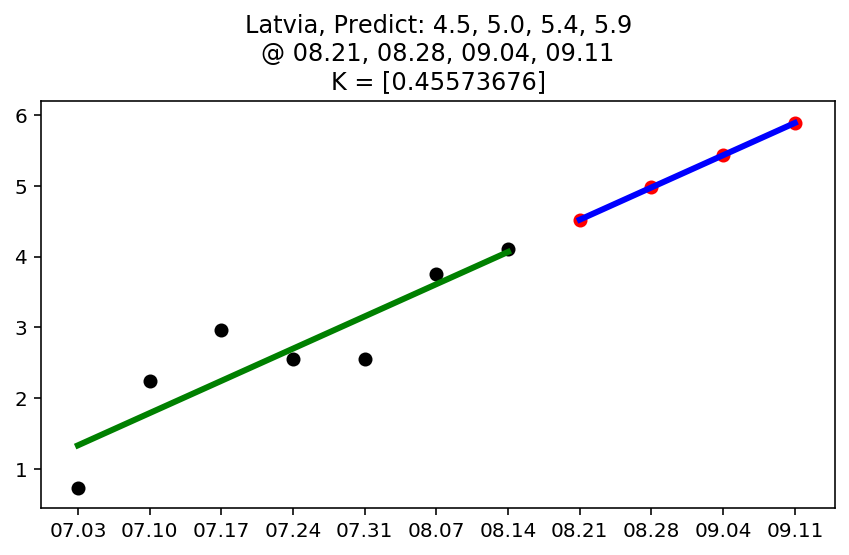

In [11]:
country = 'Latvia'
dt_range = ('2020-07-01', '2020-09-01')
len_predict = 4

days_fr, rate_14_day = get_data(df, country, dt_range)
X, X_pred, x_days = create_x(days_fr, len_predict)
y = rate_14_day

predict_lr(country, X, y, X_pred, x_days)

## Norway

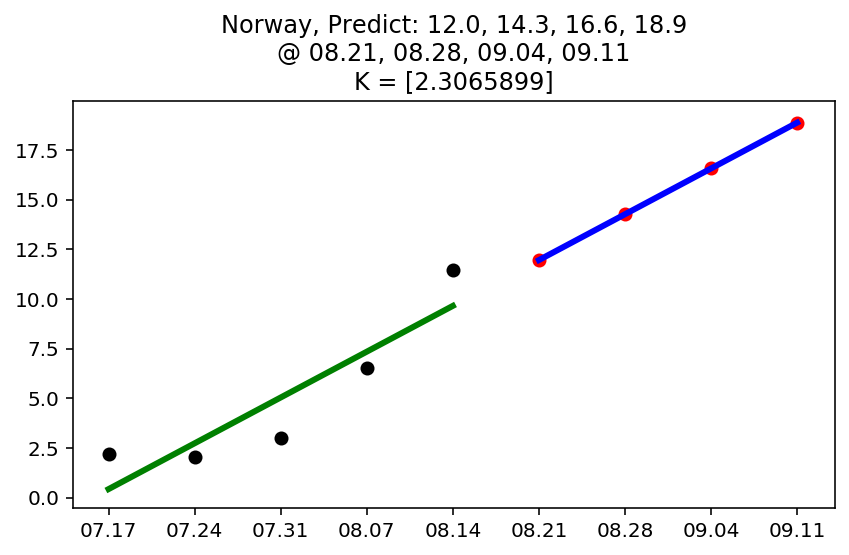

In [20]:
country = 'Norway'

dt_range = ('2020-07-17', '2020-09-01')
len_predict = 4

days_fr, rate_14_day = get_data(df, country, dt_range)
X, X_pred, x_days = create_x(days_fr, len_predict)
y = rate_14_day

predict_lr(country, X, y, X_pred, x_days)

## UK

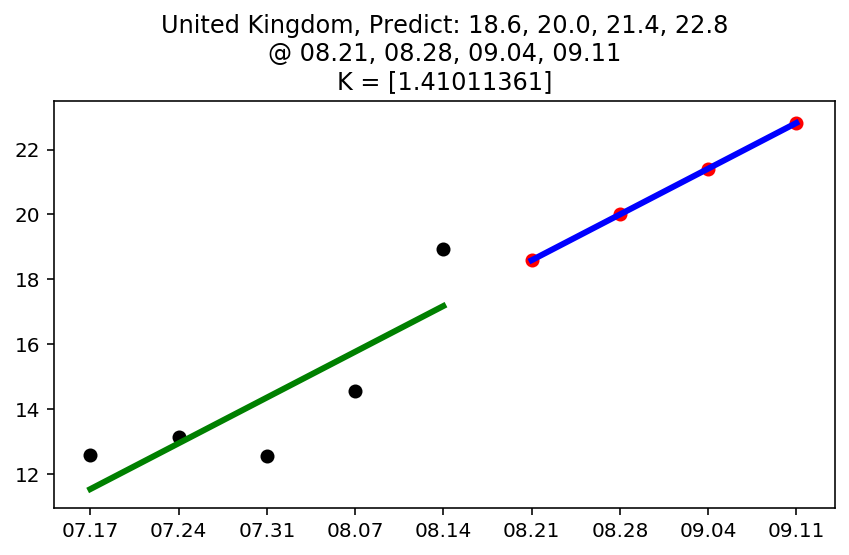

In [21]:
country = 'United Kingdom'

dt_range = ('2020-07-17', '2020-09-01')
len_predict = 4

days_fr, rate_14_day = get_data(df, country, dt_range)
X, X_pred, x_days = create_x(days_fr, len_predict)
y = rate_14_day

predict_lr(country, X, y, X_pred, x_days)

## France

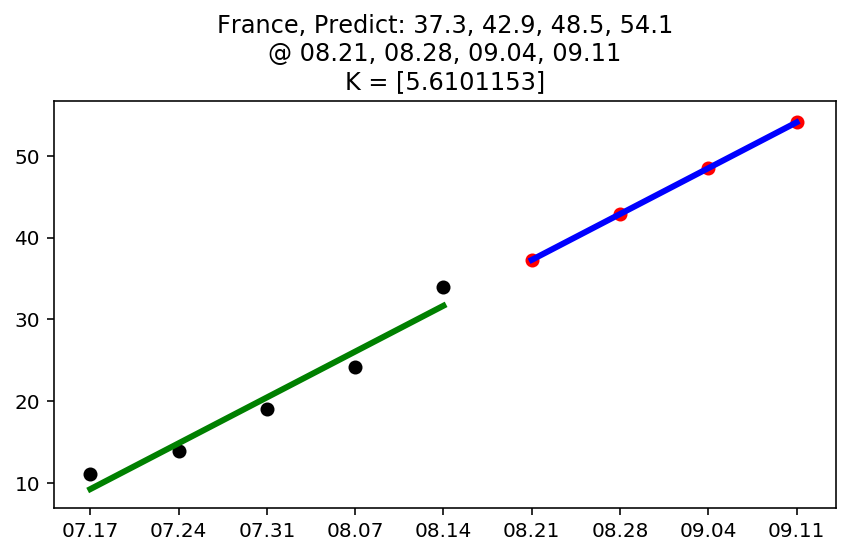

In [22]:
country = 'France'

dt_range = ('2020-07-17', '2020-09-01')
len_predict = 4

days_fr, rate_14_day = get_data(df, country, dt_range)
X, X_pred, x_days = create_x(days_fr, len_predict)
y = rate_14_day

predict_lr(country, X, y, X_pred, x_days)

## Cyprus

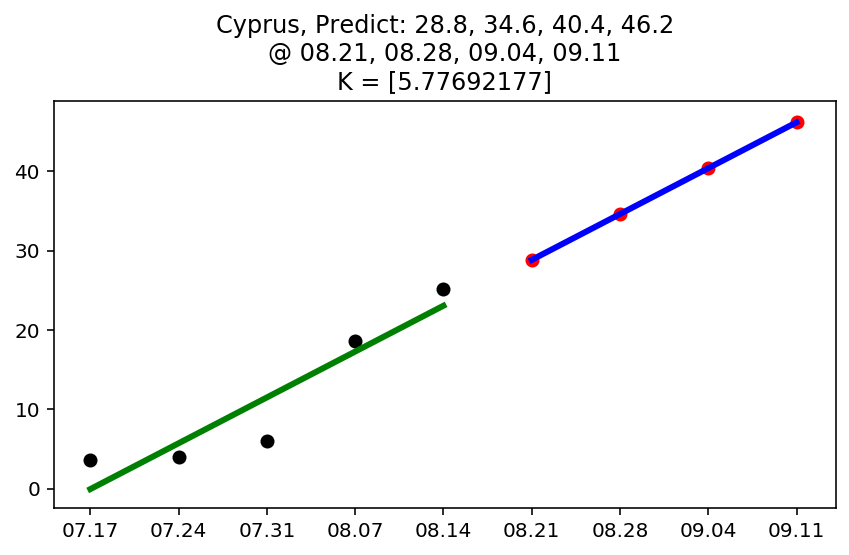

In [23]:
country = 'Cyprus'

dt_range = ('2020-07-17', '2020-09-01')
len_predict = 4

days_fr, rate_14_day = get_data(df, country, dt_range)
X, X_pred, x_days = create_x(days_fr, len_predict)
y = rate_14_day

predict_lr(country, X, y, X_pred, x_days)